In [10]:
import audioflux as af
from audioflux.type import WindowType
import subprocess
import os
import numpy as np
import csv
import sounddevice as sd
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import pandas as pd

In [5]:
# 1: get slices 
FILE_PATH = r"corpus\metro_sample_2.wav"
OUTPUT_SLICE_PATH = os.path.join("slicing_index/", "metro_sample_1.csv")

In [51]:
import wave

with wave.open(FILE_PATH, 'rb') as wav_file:
    sample_rate = wav_file.getframerate()
    
print(f"Sample Rate: {sample_rate} Hz")

Sample Rate: 48000 Hz


Obtaining the slice indices straight from the wav file using FluCoMa's OnsetSlicer. 
The onset slicer slices based on perceptual differences obtained from the spectral representations (or other) of the sound. By comparing subsequent analysis windows, and looking for either differences in Phase, Spectral Flux, KL Divergence, a subsequent window is either an onset of a new/ different sound, or not. 

In [3]:
command = [
    "fluid-onsetslice",
    "-source", FILE_PATH,
    "-indices", OUTPUT_SLICE_PATH,
    "-metric", "9", # rectified phase dev. How much the next spectral image differs from the anticipated prior
    "-threshold", "0.2"
]
try:
    result = subprocess.run(
        command, 
        check=True,          
        capture_output=True, 
        text=True            
    )
except subprocess.CalledProcessError as e:
    print("Error details:", e.stderr)

Here I extract the chromas of each slice

In [4]:
with open(OUTPUT_SLICE_PATH, "r") as f:
    reader = csv.reader(f)
    data = [int(i) for i in list(reader)[0]]

audio_arr, sr = af.read(FILE_PATH, samplate=48000)
grains_chromas = []
for i in range(len(data)-1):
#     sd.play(audio_arr[data[i]:data[i+1]], sr)
#     sd.wait()
    grain = audio_arr[data[i]:data[i+1]]
    chroma_grain_arr = af.chroma_cqt(grain, samplate=sr)
    chroma_mean_arr = np.mean(chroma_grain_arr, axis=1)
    max_chromatic_val = np.argmax(chroma_mean_arr)
    grains_chromas.append(max_chromatic_val)


In [ ]:
d = {"x": []}
d["d"] = d.get("d", [])


{'x': [], 'd': []}

In [28]:
chromas_dict = {}
for idx, key in enumerate(grains_chromas):
    chromas_dict[key] = chromas_dict.get(key, []) 
    chromas_dict[key].append(idx) # the index here corresponds to a grains index in the original audio sample. 

Only using the grains that have max mean chromatic value for the note A

In [ ]:
# count_chromas = {}
# for i in grains_chromas:
#     count_chromas[i] = count_chromas.get(i, 0) + 1
grain_indices = []
note = 10
for i, c in enumerate(grains_chromas):
    if c == note:
        grain_indices.append(i)
np.random.seed(111)

audio_arr, sr = af.read(FILE_PATH, samplate=48000)
# select 20 grains to make our asynchronous cloud
cloud_duration = 1 # number of seconds seconds
cloud_size = sr * cloud_duration 
n_streams = 50
grains = np.random.choice(grain_indices, n_streams)
output_buffer = np.zeros(cloud_size)
grain_density_max = 10
output_asynchronous = f"output/asynchronous_cloud_key_{note}_{cloud_duration}s_{n_streams}_streams_{grain_density_max}_max_density_2.wav"

for j in range(n_streams):
    main_grain = data[grains[j]] # super grain starting index
    grain_density = np.random.randint(1, 20) # once or max per second

    cloud_duration = np.max([cloud_duration,1])
    for k in range(cloud_duration):
        lower_bound = (k)*sr
        upper_bound = (k+1)*sr
        for l in range(grain_density):
            grain_duration = np.random.randint(40, 100) # 40-100 ms
            grain_size = grain_duration * 48 # in samples: 1ms is 48 samples with our sample rate
            grain_start = np.random.randint(lower_bound, upper_bound) # for the grain position
            grain_end = grain_start + grain_size # for the grain position
            if grain_end > cloud_size:
                grain_end = cloud_size
            grain_end_audio_arr = main_grain+grain_size # the actual end index of the grain sampled from the input buffer
            grain = audio_arr[main_grain: grain_end_audio_arr]
            if len(grain) > grain_end-grain_start:
                grain = grain[:grain_end-grain_start] 
            grain = grain*np.hanning(len(grain))
            
            output_buffer[grain_start: grain_end] += grain

if np.max(np.abs(output_buffer)) > 0:
    output_buffer = output_buffer / np.max(np.abs(output_buffer))
sf.write(output_asynchronous, output_buffer, samplerate=sr)

Extracting the exstimated pitch of a sound using AF

In [ ]:
sr = 48000
audio_arr, sr = af.read(FILE_PATH, samplate=sr)
pitch_obj = af.PitchYIN(samplate=sr)
fre_arr, v1_arr, v2_arr = pitch_obj.pitch(audio_arr)


c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


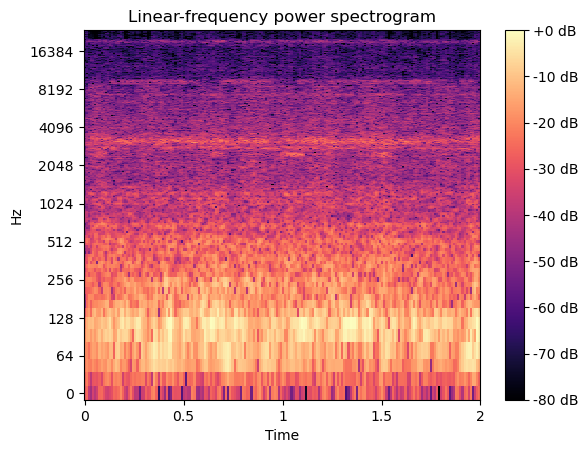

In [62]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(output_buffer)), ref=np.max)
fig, ax = plt.subplots()
img = librosa.display.specshow(data=D,y_axis='log', x_axis='time', sr=sr, ax=ax)
ax.set(title='Linear-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")


Need to slice an input audio, in short enough snippets: between 40-100 ms (Microsound ch3,5) 
such that I am slicing based on frequency content/ harmonic content

Logistic mapping function: 
$$x_{n+1} = r x_n(1-x_n)$$

In [4]:
np.random.seed(1)
grain_indices = []
note = 2 # note: A = 10
for i, c in enumerate(grains_chromas):
    if c == note:
        grain_indices.append(i)
n_grains = 4
grains = np.random.choice(grain_indices, n_grains)

# for j in range(n_grains):
#     main_grain = data[grains[j]] # super grain starting index


In [7]:
np.random.seed(1)
grain_indices = []
note = 2 # note: A = 10
for i, c in enumerate(grains_chromas):
    if c == note:
        grain_indices.append(i)
n_grains = 20
grains = np.random.choice(grain_indices, n_grains)

# for j in range(n_grains):
#     main_grain = data[grains[j]] # super grain starting index


In [ ]:
audio_arr, sr = af.read(FILE_PATH, samplate=sr, is_mono=False)

array([ True,  True,  True, ...,  True,  True,  True], shape=(4499456,))

In [9]:
# logistic mapping function
# x_n1 = r*x_n*(1-x_n)
"""
If we have a time subsequence t in which we can organize some grain(s) according to the variable x_n+1 
decided by its prior value x_n, where the range of increasing r (typically, 0-4) relates to our total
time sequences T. 

Can use x_n-1 to determine ratio of value in the left and right channel? 
"""
sr = 48000
audio_arr, sr = af.read(FILE_PATH, samplate=sr)
iterations = 4
r_start = 2
r_end = 4
incr = (r_end-r_start)/iterations
x_n = 0.2
t_seconds = 0.2
t_samples = int(t_seconds * sr)
# output_total_samples = iterations * t_samples
output_buffer = np.array([[],[]])
max_grain_size = 1000
output_file_path = f"output/TEST_2_logistic_map_gs_{note}_key_{iterations}_iter_{r_start}_r_start_{r_end}_r_end_{x_n}_x_start_{t_seconds}_t_seconds.wav"
# output_file_path = "testtest.wav"

for i in range(iterations):

    grain_buffer = np.zeros(t_samples)
    grain_idx = np.random.choice(grains) # grain idx within grains_chroma array
    grain_arr_idx = data[grain_idx] # grain index within main audio array
    grain_size = np.random.randint(10, np.min([max_grain_size,t_samples]))
    grain = audio_arr[grain_arr_idx: grain_arr_idx+grain_size]
    grain_buffer_size = len(grain_buffer)
    grain_pos = int(x_n * t_samples // 1)
    grain_end = grain_pos+grain_size if not grain_size+grain_pos > grain_buffer_size else grain_buffer_size
    grain_len = len(grain) if grain_end-grain_pos > len(grain) else grain_end-grain_pos
    grain = grain[:grain_len]
    # exp window 
    lin_func = np.linspace(0, 5, grain_len) # 5 here is arbitrary, controls the steepness
    window = 1 - np.exp(-lin_func)
    window = (window - window.min()) / (window.max() - window.min()) # normalize
    # window = np.hanning(grain_len)
    grain_buffer[grain_pos:grain_end] += grain*window

    channel = 1 if np.random.uniform() < 0.5 else 0 # uniform selection of channel assignment of amplitudes
    # print(channel)
    x_n = r_start*x_n*(1-x_n)
    x_n_1 = r_start*x_n*(1-x_n)
    r_start += incr
    l, r = x_n, x_n_1
    empty_grain_buffer = np.zeros(grain_buffer_size)

    # if channel == 1:
    #     grain_buffer = np.array([grain_buffer, empty_grain_buffer]) # maybe use vstack here instead. 
    # else:
    #     grain_buffer = np.array([empty_grain_buffer, grain_buffer])

    if channel == 1:
        # print(grain_buffer.shape)
        # print(l,r)
        new_buffer = np.array([l*grain_buffer, r*grain_buffer])
    else:
        new_buffer = np.array([r*grain_buffer, l*grain_buffer])
    # print(grain_buffer.shape)
    # print(output_buffer.shape)
    output_buffer = np.concatenate((output_buffer, new_buffer), axis=1)



if np.max(np.abs(output_buffer)) > 0:
    output_buffer = output_buffer / np.max(np.abs(output_buffer))
output_buffer = output_buffer.T #np.reshape(output_buffer, (output_buffer.shape[1], output_buffer.shape[0]))
sf.write(output_file_path, output_buffer, samplerate=sr)


In [43]:
sr = 48000
audio_arr, sr = af.read(FILE_PATH, samplate=sr)
iterations = 1000
r_start = 3.2
r_end = 4
incr = (r_end-r_start)/iterations
x_n = 0.2

# grain_density = 20 # Hz
grain_size = 100 
np.random.seed(1)
output_buffer = np.array([])
# print(output_buffer)
for _ in range(iterations):
    key = int(x_n * 12 // 1)
    grains_in_key = chromas_dict[key] # array of grain indexes
    grain_index_arr = data[np.random.choice(grains_in_key)]
    grain_end_index_arr = grain_index_arr+grain_size
    if grain_end_index_arr > audio_arr.shape[-1]:
        grain_end_index_arr = audio_arr.shape[-1]
    grain = audio_arr[grain_index_arr: grain_end_index_arr]
    grain = grain * np.hanning(len(grain))
    print(np.max(grain))
    output_buffer = np.concatenate((output_buffer, grain))
    output_buffer = np.concatenate((output_buffer, np.zeros(len(grain)*10)))
sf.write("output/synchronous_gs_test.wav", output_buffer, samplerate=sr)

-0.0
-0.0
0.12145387180021121
0.056351282359621314
-0.0
-0.0
-0.0
0.23438896439483417
0.23438896439483417
0.3541073820089494
0.12145387180021121
0.0006532877641178443
0.12145387180021121
0.05929451579769652
-0.0
0.06166375795586349
0.00011101752903788958
-0.0
0.06166375795586349
0.00011101752903788958
-0.0
0.12145387180021121
0.38368600093481975
0.12145387180021121
0.06166375795586349
0.00011101752903788958
0.0006532877641178443
0.0006532877641178443
-0.0
0.3541073820089494
0.0006532877641178443
0.23438896439483417
0.05929451579769652
-0.0
-0.0
0.0006532877641178443
0.05929451579769652
-0.0
0.3541073820089494
0.23438896439483417
0.12145387180021121
0.3541073820089494
0.056351282359621314
0.056351282359621314
0.33783433698837595
0.38368600093481975
-0.0
0.056351282359621314
0.0006532877641178443
0.33783433698837595
0.05929451579769652
-0.0
0.3541073820089494
-0.0
0.33783433698837595
0.00011101752903788958
0.056351282359621314
0.3541073820089494
-0.0
0.12145387180021121
0.383686000934819